In [ ]:
import numpy as np
import matplotlib.pyplot as plt

### Function for the random step
create the random increments of a time series as random walk

$DX$ is the standard deviation, $bias$ is the constant average of the step

In [2]:
def pattern(i,z,a):
    return int(a*np.sin((np.pi*i)/z))

# random seed for reproducibility
np.random.seed(12345)
jump = lambda drift, stdev: int(np.random.normal(drift,stdev))

for i in range(10):
    print(jump(5,50))

-5
28
-20
-22
103
74
9
19
43
67


### Function for the added pattern
to add to part of a time series, over $z$ bins, with amplitude $a$

mkdir: DATA: File exists
ts_L60_Z12_A50_DX50_bias5_N10000.dat
ts_L60_Z12_A100_DX50_bias5_N10000.dat
ts_L60_Z12_A150_DX50_bias5_N10000.dat
ts_L60_Z12_A200_DX50_bias5_N10000.dat
ts_L60_Z12_A250_DX50_bias5_N10000.dat
ts_L60_Z12_A300_DX50_bias5_N10000.dat
ts_L60_Z12_A350_DX50_bias5_N10000.dat
ts_L60_Z12_A400_DX50_bias5_N10000.dat
ts_L60_Z12_A450_DX50_bias5_N10000.dat
ts_L60_Z12_A500_DX50_bias5_N10000.dat
ts_L60_Z12_A550_DX50_bias5_N10000.dat
ts_L60_Z12_A600_DX50_bias5_N10000.dat
ts_L60_Z12_A650_DX50_bias5_N10000.dat
ts_L60_Z12_A700_DX50_bias5_N10000.dat
ts_L60_Z12_A750_DX50_bias5_N10000.dat
ts_L60_Z12_A800_DX50_bias5_N10000.dat
ts_L60_Z12_A850_DX50_bias5_N10000.dat
ts_L60_Z12_A900_DX50_bias5_N10000.dat
ts_L60_Z12_A950_DX50_bias5_N10000.dat


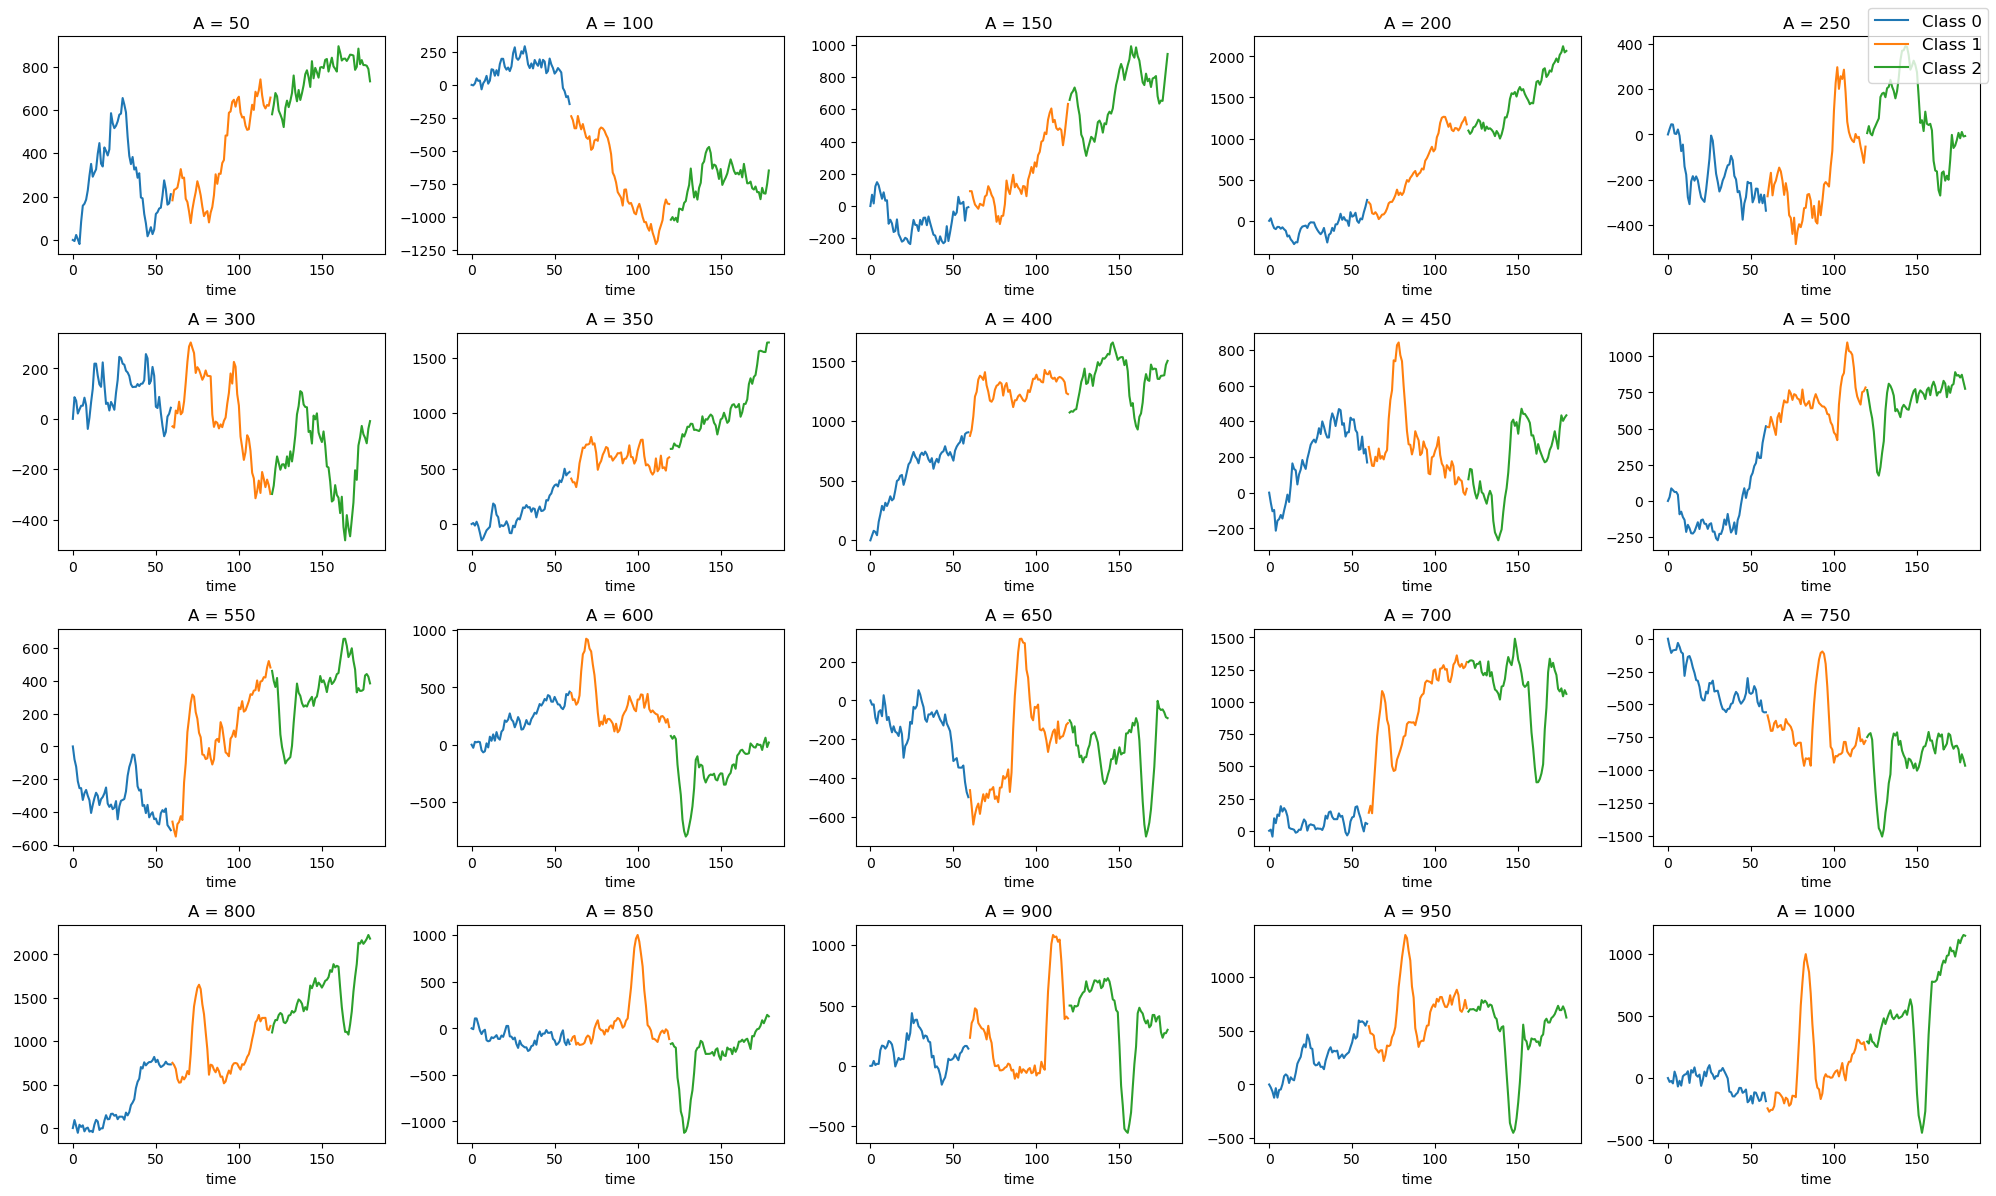

ts_L60_Z12_A1000_DX50_bias5_N10000.dat


In [3]:
#List of different values for A
Arange=np.arange(50,1050,50)

#Parameters for the Plot
num_plots = len(Arange)
cols = 5
rows = (num_plots + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, 3 * rows))
axes = axes.flatten()
current_plot_idx = 0

#Redefinition of Show_data to get a multiplot

def Show_data(x, L, s="data"):
    global current_plot_idx
    if current_plot_idx < len(axes):
        ax = axes[current_plot_idx]

        #Secuential plot
        ax.plot(np.arange(L), x[0], label='Class 0')
        ax.plot(np.arange(L, 2*L), x[1], label='Class 1')
        ax.plot(np.arange(2*L, 3*L), x[2], label='Class 2')
        
        # Calculate current A based on index
        current_A = 50 + current_plot_idx * 50
        ax.set_title(f'A = {current_A}')
        ax.set_xlabel("time")
        current_plot_idx += 1
        
    # When reached the last plot, render the final multiplot
    if current_plot_idx == num_plots:
        for i in range(num_plots, len(axes)):
            fig.delaxes(axes[i])
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper right', fontsize='large')
        plt.tight_layout()
        plt.show()

def pattern(i, z, a):
    return int(a * np.sin((np.pi * i) / z))

np.random.seed(12345)
!mkdir DATA
Z=12
#Generation of list of diferent amplitudes
for A in Arange:
    N=10000
    L=60
    DX = 50 
    bias = 5 

    y = [0] * N # initialize class labels with zeros
    x = [[0] * L for i in range(N)] # initialize timeseries with zeros

    for i in range(N):
        if i>0:
            x[i][0] = x[i-1][-1] + jump(bias,DX) # first step of the new sample starts from the last point of the previous one

        for j in range(1,L):
            x[i][j] = x[i][j-1] + jump(bias,DX) # random walk with bias

        y[i] = i%3 # assign class labels
        if y[i]>0:
            j0 = np.random.randint(0,L-1-Z) # random starting point for the pattern
            sign = 3-2*y[i] # sign of the pattern: + for class 1, - for class 2
            for j in range(Z):
                x[i][j0+j] += sign*pattern(j,Z,A) # add pattern to the timeseries

    Show_data(x,L,"original data")

    str0 = f'ts_L{L}_Z{Z}_A{A}_DX{DX}_bias{bias}_N{N}.dat'
    print(str0)
    fname='DATA/x_'+str0
    np.savetxt(fname,x,fmt="%d")
    fname='DATA/y_'+str0
    np.savetxt(fname,y,fmt="%d")